# Synthetic Extended Runs — Analysis

Compares water-balance response across domain/model setups driven by alternating wet (WY2011) and dry (WY2012) forcing patterns.

**East River setups:** elev × {bigBuckt, noXplict}; elevTPI × {bigBuckt, noXplict}  
**Tuolumne setups:** elev × {noXplict, qTopmodl}; elevTPI × {noXplict, qTopmodl}  
**Patterns:** alt_1w1d … dry10_wet10 (10–20 year runs)

All depth variables (Q, P, ET, SWE) are in mm yr⁻¹ — already area-normalized depth equivalents.  
**Figures are split by basin** (East River left, Tuolumne right) so absolute values are comparable within each panel.  
Dimensionless ratios (runoff ratio, ET/P) share a common y-axis for cross-basin comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

CSV = Path('/scratch/dlhogan/ess-project-data/synthetic_summary.csv')
df  = pd.read_csv(CSV)

# ── Domain ordering: top 2 = East River, bottom 2 = Tuolumne ─────────────────
DOMAIN_ORDER = [
    'East_River_distributed',
    'East_River_distributed_elevTPI',
    'Tuolumne_River_distributed_elev',
    'Tuolumne_River_distributed_elevTPI',
]
DOMAIN_LABELS = {
    'East_River_distributed'            : 'East River · Elev',
    'East_River_distributed_elevTPI'    : 'East River · Elev+TPI',
    'Tuolumne_River_distributed_elev'   : 'Tuolumne River · Elev',
    'Tuolumne_River_distributed_elevTPI': 'Tuolumne River · Elev+TPI',
}

MODEL_ORDER   = ['bigBuckt', 'noXplict', 'qTopmodl']
MODEL_COLORS  = {'bigBuckt': '#4878CF', 'noXplict': '#D65F5F', 'qTopmodl': '#6ACC65'}
MODEL_MARKERS = {'bigBuckt': 'o',       'noXplict': 's',       'qTopmodl': '^'}

ALT_PATTERNS = ['alt_1w1d', 'alt_2w2d', 'alt_3w3d', 'alt_4w4d', 'alt_5w5d_wf', 'alt_5w5d_df']
ALT_LABELS   = {
    'alt_1w1d'    : '1W·1D',
    'alt_2w2d'    : '2W·2D',
    'alt_3w3d'    : '3W·3D',
    'alt_4w4d'    : '4W·4D',
    'alt_5w5d_wf' : '5W·5D',
    'alt_5w5d_df' : '5W·5D',
}
BLOCK_PATTERNS = ['wet10_dry10', 'dry10_wet10']
BLOCK_LABELS   = {
    'wet10_dry10': '10 Wet → 10 Dry',
    'dry10_wet10': '10 Dry → 10 Wet',
}

WET_COLOR = '#2166ac'
DRY_COLOR = '#b2182b'

# Storage: july SWE + soil moisture + aquifer (bigBuckt only, m → mm)
# min_aquifer_mm column stores values in metres despite the name
df['aquifer_mm']      = np.where(df['model'] == 'bigBuckt', df['min_aquifer_mm'] * 1000, 0.0)
df['total_storage_mm'] = df['july_swe_mm'] + df['mean_soil_liq_mm'] + df['aquifer_mm']

print(f"Rows: {len(df)}")
print("Domains:", df['domain'].unique().tolist())
print("Patterns:", df['pattern'].unique().tolist())
df.head(3)

Rows: 816
Domains: ['East_River_distributed', 'East_River_distributed_elevTPI', 'Tuolumne_River_distributed_elev', 'Tuolumne_River_distributed_elevTPI']
Patterns: ['alt_1w1d', 'alt_2w2d', 'alt_3w3d', 'alt_4w4d', 'alt_5w5d_wf', 'alt_5w5d_df', 'wet10_dry10', 'dry10_wet10']


,domain,model,pattern,water_year,year_idx,year_type,total_q_mm,total_p_mm,runoff_ratio,total_et_mm,peak_swe_mm,peak_swe_dowy,july_swe_mm,days_with_snow,mean_soil_liq_mm,min_aquifer_mm,peak_q_dowy,com_q_dowy,aquifer_mm,total_storage_mm
0,East_River_distributed,bigBuckt,alt_1w1d,2021,0,W,540.13,1012.72,0.5333,373.60,551.76,215.0,2.79,261,159.09,0.0825,243.0,255.8,82.5,244.38
1,East_River_distributed,bigBuckt,alt_1w1d,2022,1,D,160.48,583.05,0.2752,415.15,192.52,155.0,0.00,218,154.91,0.0939,179.0,182.0,93.9,248.81
2,East_River_distributed,bigBuckt,alt_1w1d,2023,2,W,516.23,1012.72,0.5097,374.35,551.65,215.0,2.79,266,159.44,0.0763,243.0,262.1,76.3,238.53


## Transition-Year Water Balance Timeseries

Daily timeseries for the **final transition water year** of each model × pattern combination:
- **Block patterns** (`wet10_dry10`, `dry10_wet10`): WY2031 — the first year after the 10-year drought or deluge
- **Alternating patterns** (`alt_*`): WY2040 — the final year of the run

Rows: streamflow · SWE · subsurface storage (soil + aquifer) · ET+sublimation  
Colors: groundwater parameterization · Line style: domain discretization (solid=Elev, dashed=ElevTPI)  
Block patterns are drawn opaque; alternating patterns are drawn as faint background spaghetti.

In [2]:
import warnings
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

warnings.filterwarnings('ignore')

BASE  = Path('/scratch/dlhogan/ess-project-data')
SYNTH = 'synthetic_extended_runs'

DOMAIN_MODEL = {
    'East_River_distributed_elevAspect':     'bigBuckt',
    'Tuolumne_River_distributed_elevTPI': 'qTopmodl',
}
DOMAIN_LABELS_FIG = {
    'East_River_distributed_elevAspect':     'East River · Elev+Aspect  (bigBuckt)',
    'Tuolumne_River_distributed_elevTPI': 'Tuolumne · Elev+TPI  (qTopmodl)',
}

# Each pattern has a different run length (years):
#   alt_1w1d=10, alt_2w2d=12, alt_3w3d=12, alt_4w4d=8, alt_5w5d_*=10, blocks=20
PATTERN_N_YEARS = {
    'alt_1w1d'   : 11, 'alt_2w2d'   : 11, 'alt_3w3d'   : 10,
    'alt_4w4d'   :  9, 'alt_5w5d_wf': 11, 'alt_5w5d_df': 11,
    'wet10_dry10': 11, 'dry10_wet10': 11,
}
FIRST_WY = 2021  # WY2021 starts Oct 2020

def get_win(pattern):
    """3-year window ending at the last (or transition) WY of each pattern."""
    n = PATTERN_N_YEARS[pattern]
    if pattern in BLOCK_PATTERNS:
        last_wy = FIRST_WY + 10   # year-11 = WY2031, first year after 10-yr block
    else:
        last_wy = FIRST_WY + n - 1
    t1 = f'{last_wy}-09-30'
    t0 = f'{last_wy - 3}-10-01'
    return t0, t1

YR_BOUNDS = [1, 366, 731]

# Pre-load basin areas and HRU weights
basin_area  = {}
hru_weights = {}
for domain in DOMAIN_MODEL:
    with xr.open_dataset(
            BASE / f'domain_{domain}' / 'settings' / 'SUMMA' / 'attributes.nc') as dsa:
        a = dsa['HRUarea'].values.ravel().astype(float)
        basin_area[domain]  = float(a.sum())
        hru_weights[domain] = a / a.sum()

def _area_mean(da, w):
    arr = da.values
    if arr.ndim == 2:
        return (arr * w[None, :arr.shape[1]]).sum(axis=1)
    return arr.ravel()

def load_3yr(domain, model, pattern):
    t0, t1 = get_win(pattern)
    nc = (BASE / f'domain_{domain}' / 'simulations' / SYNTH /
          model / pattern / 'output' /
          f'synthetic_{domain}_{model}_{pattern}_timestep.nc')
    if not nc.exists():
        print(f'  MISSING: {nc.name}')
        return None

    w    = hru_weights[domain]
    area = basin_area[domain]
    ref  = pd.Timestamp(t0)

    ds  = xr.open_dataset(nc).sel(time=slice(t0, t1))
    ti  = pd.DatetimeIndex(ds.time.values)
    if len(ti) == 0:
        print(f'  EMPTY SLICE: {domain}/{model}/{pattern}  window={t0}:{t1}')
        ds.close(); return None

    # ── Streamflow (m³/s daily mean)
    q_d = (pd.Series(ds['averageRoutedRunoff'].mean(dim='gru').values.ravel() * area, index=ti)
             .resample('1D').mean())

    # ── SWE (kg/m² = mm, area-weighted daily mean)
    swe_arr = _area_mean(ds['scalarSWE'], w)
    swe_d   = pd.Series(swe_arr, index=ti).resample('1D').mean()

    # ── Total storage in numpy space (avoids pandas alignment issues)
    #    SWE + soil liq + soil ice + aquifer (all in mm)
    soil_arr = _area_mean(ds['scalarTotalSoilLiq'], w).copy()
    if 'scalarTotalSoilIce' in ds:
        soil_arr += _area_mean(ds['scalarTotalSoilIce'], w)
    aq_arr = np.zeros(len(swe_arr))
    if 'scalarAquiferStorage_mean' in ds:
        aq_arr = _area_mean(ds['scalarAquiferStorage_mean'], w) * 1000  # m -> mm
    total_arr = swe_arr + soil_arr + aq_arr
    total_d   = pd.Series(total_arr, index=ti).resample('1D').mean()
    cum_stor  = total_d - float(total_d.iloc[0])

    # ── ET + sublimation (monthly mm)
    et_arr = _area_mean(ds['scalarTotalET'], w).copy()
    for v in ('scalarCanopySublimation', 'scalarSnowSublimation'):
        if v in ds:
            et_arr += _area_mean(ds[v], w)
    et_daily   = pd.Series(np.abs(et_arr) * 3600, index=ti).resample('1D').sum()
    et_monthly = et_daily.resample('MS').sum()
    et_m_rel   = ((et_monthly.index + pd.Timedelta(days=15) - ref).days + 1).values

    ds.close()
    rel = (q_d.index - ref).days + 1
    return {
        'q':        pd.Series(q_d.values,        index=rel),
        'swe':      pd.Series(swe_d.values,      index=rel),
        'cum_stor': pd.Series(cum_stor.values,   index=rel),
        'et_m':     pd.Series(et_monthly.values, index=et_m_rel),
    }

print("Loading 3-year windows...", flush=True)
all_data = {}
for domain, model in DOMAIN_MODEL.items():
    for pattern in BLOCK_PATTERNS + ALT_PATTERNS:
        t0, t1 = get_win(pattern)
        d = load_3yr(domain, model, pattern)
        if d is not None:
            all_data[(domain, model, pattern)] = d
        print(f'  {domain[:20]} / {model} / {pattern} [{t0}:{t1}]: {"OK" if d is not None else "SKIP"}')

print(f"\nLoaded {len(all_data)} / {len(DOMAIN_MODEL) * len(BLOCK_PATTERNS + ALT_PATTERNS)} combinations.")


Loading 3-year windows...
  East_River_distribut / bigBuckt / wet10_dry10 [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / dry10_wet10 [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / alt_1w1d [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / alt_2w2d [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / alt_3w3d [2027-10-01:2030-09-30]: OK
  East_River_distribut / bigBuckt / alt_4w4d [2026-10-01:2029-09-30]: OK
  East_River_distribut / bigBuckt / alt_5w5d_wf [2028-10-01:2031-09-30]: OK
  East_River_distribut / bigBuckt / alt_5w5d_df [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / wet10_dry10 [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / dry10_wet10 [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / alt_1w1d [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / alt_2w2d [2028-10-01:2031-09-30]: OK
  Tuolumne_River_distr / qTopmodl / alt_3w3d [2027-10-01:2030-09-30]: OK
  Tuolu

In [9]:
stor_order

['alt_1w1d',
 'alt_3w3d',
 'alt_5w5d_wf',
 'wet10_dry10',
 'dry10_wet10',
 'alt_2w2d',
 'alt_5w5d_df']

Loading final-year data...


  alt_1w1d WY2030 (D): aug_swe=87 mm  soil=234 mm
  alt_3w3d WY2030 (D): aug_swe=223 mm  soil=218 mm
  alt_5w5d_wf WY2030 (D): aug_swe=113 mm  soil=208 mm
  wet10_dry10 WY2031 (D): aug_swe=1295 mm  soil=194 mm
  alt_2w2d WY2030 (W): aug_swe=346 mm  soil=297 mm
  alt_5w5d_df WY2030 (W): aug_swe=679 mm  soil=292 mm
  dry10_wet10 WY2031 (W): aug_swe=126 mm  soil=315 mm


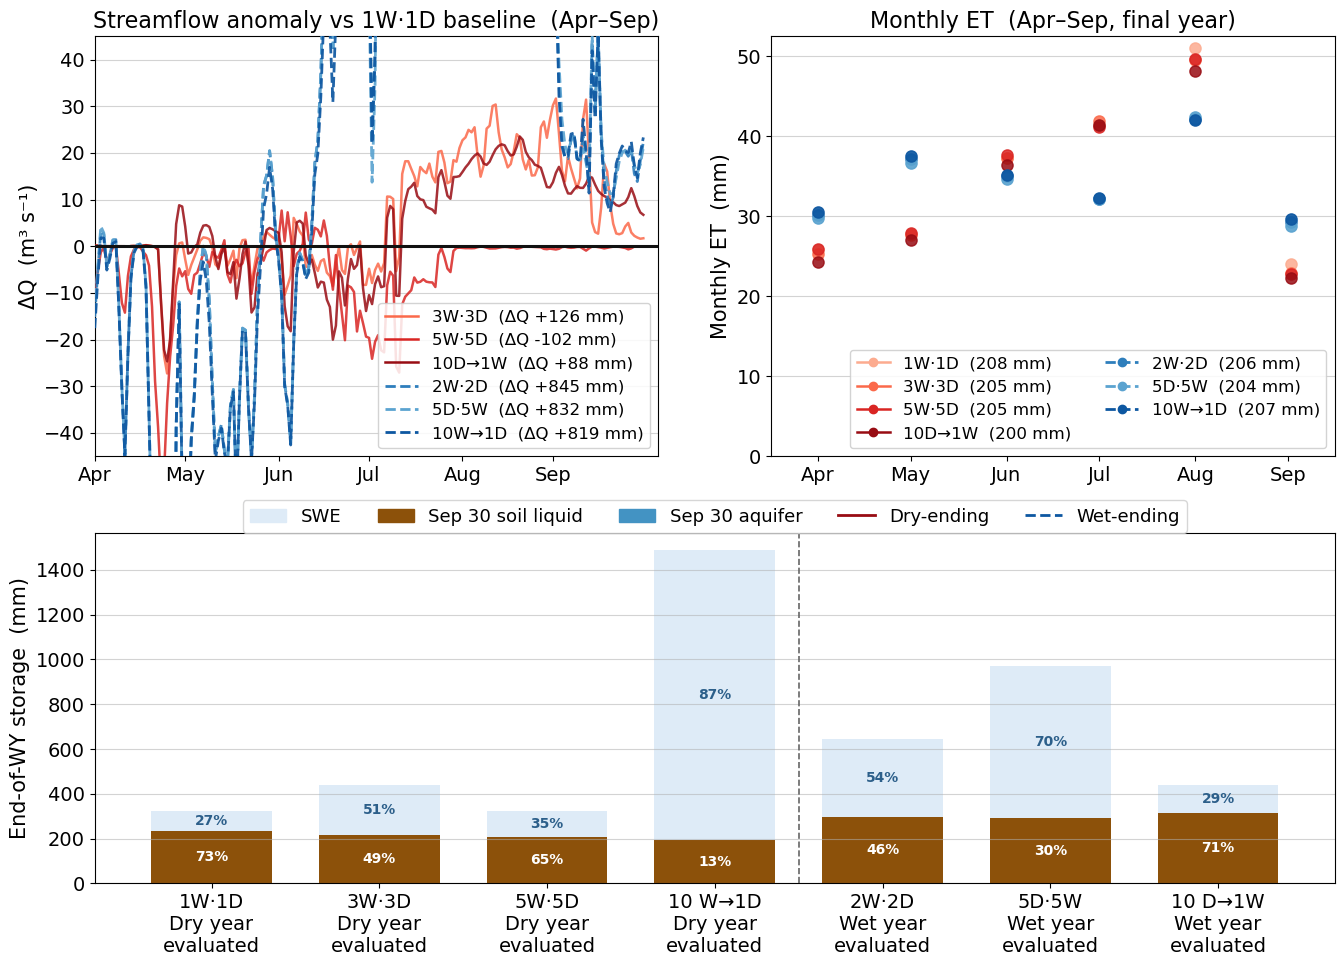

Saved → ess-project/figures/synthetic_fig_ensemble_style.png


In [16]:
# Spring-Ensemble-style figure for synthetic runs
# Top-left : Q anomaly vs alt_1w1d baseline  (Apr–Sep, final year)
# Top-right: Monthly ET scatter              (Apr–Sep, final year)
# Bottom   : Stacked storage bars — dry-evaluated left, wet-evaluated right

import sys, warnings
import xarray as xr, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches, matplotlib.lines as mlines
import matplotlib.cm as cm
from pathlib import Path

warnings.filterwarnings('ignore')

BASE  = Path('/scratch/dlhogan/ess-project-data')
SYNTH = 'synthetic_extended_runs'

FOCUS_DOMAIN = 'Tuolumne_River_distributed_elevTPI'
FOCUS_MODEL  = 'qTopmodl'

# Linear reservoir routing parameters (calibrated for Tuolumne)
LR_PARAMS = {'k_fast': 0.8641534245539414, 'k_slow': 0.47518306157180934, 'f': 1.0}
# LR_PARAMS = {'k_fast': 0.47522528151425714, 'k_slow': 2.4805360274754705e-05, 'f': 0.8004766558786294}
# LR_PARAMS = {'k_fast': 0.4729497280965281, 'k_slow': 2.1803944632295235e-05, 'f': 0.7853809118991199}

DRY_END   = ['alt_1w1d', 'alt_3w3d', 'alt_5w5d_wf', 'wet10_dry10', ]
WET_END   = ['alt_5w5d_df', 'alt_2w2d', 'dry10_wet10']

BAR_ORDER = ['alt_1w1d', 'alt_3w3d',
             'alt_5w5d_wf', 'wet10_dry10','alt_2w2d','alt_5w5d_df', 'dry10_wet10',
             ]

# last fully-simulated water year per pattern
FINAL_WY = {
    'alt_1w1d':    2030, 'alt_2w2d':    2030, 'alt_3w3d':    2030,
    'alt_5w5d_wf': 2030, 'alt_5w5d_df': 2030,
    'wet10_dry10': 2031, 'dry10_wet10': 2031,
}
LABELS = {
    'alt_1w1d': '1W·1D', 'alt_2w2d': '2W·2D', 'alt_3w3d': '3W·3D',
    'alt_5w5d_wf': '5W·5D', 'alt_5w5d_df': '5D·5W',
    'wet10_dry10': '10D→1W', 'dry10_wet10': '10W→1D',
}

DRY_CMAP = dict(zip(DRY_END, cm.Reds(np.linspace(0.30, 0.90, len(DRY_END)))))
WET_CMAP = dict(zip(WET_END, cm.Blues( np.linspace(0.55, 0.85, len(WET_END)))))
BLUE_REP = DRY_CMAP[DRY_END[-1]]
RED_REP  = WET_CMAP[WET_END[-1]]

def _style(pat):
    if pat in WET_END: return WET_CMAP[pat], 2.0, '--', 4, 0.92
    return DRY_CMAP[pat], 1.8, '-', 3, 0.85

# ── HRU weights ───────────────────────────────────────────────────────────
with xr.open_dataset(BASE / f'domain_{FOCUS_DOMAIN}/settings/SUMMA/attributes.nc') as _ds:
    _a = _ds['HRUarea'].values.ravel().astype(float)
    BASIN_AREA = float(_a.sum())
    HRU_W = _a / _a.sum()

def _am(da):
    arr = da.values
    return (arr * HRU_W[None, :arr.shape[1]]).sum(axis=1) if arr.ndim == 2 else arr.ravel()

def route_linear_reservoir(q_m3s, k_fast, k_slow, f, area_m2):
    """Two-parallel linear reservoir routing (daily, mm/day ↔ m³/s)."""
    R = q_m3s.values * 86400 / area_m2 * 1000  # m³/s → mm/day
    n = len(R)
    S_fast = np.zeros(n)
    S_slow = np.zeros(n)
    Q = np.zeros(n)
    sf, ss = 0.0, 0.0
    for t in range(n):
        Q[t] = k_fast * sf + k_slow * ss
        S_fast[t] = (1 - k_fast) * sf + f * R[t]
        S_slow[t] = (1 - k_slow) * ss + (1 - f) * R[t]
        sf, ss = S_fast[t], S_slow[t]
    return pd.Series(Q / 1000 * area_m2 / 86400, index=q_m3s.index)  # mm/day → m³/s

_csv = pd.read_csv(BASE / 'synthetic_summary.csv')
_csv = _csv[(_csv['domain'] == FOCUS_DOMAIN) & (_csv['model'] == FOCUS_MODEL)]

APR_DOY = 183
SEP_DOY = 365

def load_final_year(pat):
    wy  = FINAL_WY[pat]
    nc  = (BASE / f'domain_{FOCUS_DOMAIN}/simulations/{SYNTH}'
           f'/{FOCUS_MODEL}/{pat}/output'
           f'/synthetic_{FOCUS_DOMAIN}_{FOCUS_MODEL}_{pat}_timestep.nc')
    if not nc.exists(): return None
    with xr.open_dataset(nc) as ds:
        # load one extra month before WY start to spin up routing
        ds  = ds.sel(time=slice(f'{wy-1}-09-01', f'{wy}-09-30'))
        ti  = pd.DatetimeIndex(ds.time.values)
        if len(ti) == 0: return None
        ref = pd.Timestamp(f'{wy-1}-10-01')

        q_raw = (pd.Series(ds['basin__TotalRunoff'].mean(dim='gru').values.ravel() * BASIN_AREA, index=ti)
                 .resample('1D').mean())
        q_routed = route_linear_reservoir(q_raw, area_m2=BASIN_AREA, **LR_PARAMS)
        # trim to WY after spin-up month
        q_d = q_routed[q_routed.index >= pd.Timestamp(f'{wy-1}-10-01')]

        et_arr = _am(ds['scalarTotalET']).copy()
        for v in ('scalarCanopySublimation', 'scalarSnowSublimation'):
            if v in ds: et_arr += _am(ds[v])
        et_d = pd.Series(np.abs(et_arr) * 3600, index=ti).resample('1D').sum()
        et_monthly = et_d[et_d.index >= pd.Timestamp(f'{wy}-04-01')].resample('MS').sum()
        et_mo = pd.Series(et_monthly.values,
                          index=(et_monthly.index - ref).days + 1 + 15)

        soil = float(pd.Series(_am(ds['scalarTotalSoilLiq']), index=ti)
                     .resample('1D').mean().iloc[-1])

        aq_key = next((v for v in ['scalarAquiferStorage_mean', 'scalarAquiferStorage'] if v in ds), None)
        aq = (float(pd.Series(_am(ds[aq_key]) * 1000, index=ti).resample('1D').mean().iloc[-1])
              if aq_key and FOCUS_MODEL == 'bigBuckt' else 0.0)

        swe_daily = pd.Series(_am(ds['scalarSWE']), index=ti).resample('1D').mean()
        aug_swe   = float(swe_daily.get(pd.Timestamp(f'{wy}-09-30'), 0.0))

    row = _csv[(_csv['pattern'] == pat) & (_csv['water_year'] == wy)]
    year_type = str(row['year_type'].iloc[0]) if len(row) else '?'

    doy = (q_d.index - ref).days + 1
    return {'q': pd.Series(q_d.values, index=doy), 'et_mo': et_mo,
            'soil': soil, 'aq': aq, 'aug_swe': aug_swe, 'year_type': year_type}

print('Loading final-year data...')
DATA = {}
for p in BAR_ORDER:
    d = load_final_year(p)
    DATA[p] = d
    if d:
        print(f'  {p} WY{FINAL_WY[p]} ({d["year_type"]}): aug_swe={d["aug_swe"]:.0f} mm  soil={d["soil"]:.0f} mm')
    else:
        print(f'  {p}: MISSING or empty slice')

REF_PAT = 'alt_1w1d'
ref_q   = DATA[REF_PAT]['q'].reindex(range(APR_DOY, SEP_DOY + 1))

# bars: dry-evaluated first (sorted by SWE), then wet-evaluated (sorted by SWE)
valid = [p for p in BAR_ORDER if DATA.get(p)]
stor_order = (
    sorted([p for p in valid if DATA[p]['year_type'] == 'D'], key=lambda p: 0) +
    sorted([p for p in valid if DATA[p]['year_type'] == 'W'], key=lambda p: 0)
)

# ── Styling ───────────────────────────────────────────────────────────────
BLACK    = '#111111'
COL_AQ   = '#4393c3'
COL_SOIL = '#8c510a'
COL_SWE  = '#deebf7'
GRD      = dict(axis='y', lw=0.8, alpha=0.55)
FS       = dict(ti=16, ax=15, tk=14, lg=13, an=14)
PCT_MIN  = 5.0
_APR_TICKS  = [183, 213, 244, 274, 305, 335]
_APR_LABELS = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1.2, 1.0])
ax_q  = fig.add_subplot(gs[0, 0])
ax_et = fig.add_subplot(gs[0, 1])
ax_st = fig.add_subplot(gs[1, :])

# ── Q anomaly — plot lines, build legend with cumulative ΔQ ──────────────
q_handles = []
for p in BAR_ORDER:
    d = DATA.get(p)
    if p == REF_PAT:
        continue
    if not d: continue
    c, lw, ls, zo, al = _style(p)
    q_s  = d['q'].reindex(range(APR_DOY, SEP_DOY + 1))
    anom = q_s - ref_q
    ax_q.plot(anom.index, anom.values, color=c, lw=lw, ls=ls, alpha=al, zorder=zo)
    cum_dq_mm = float(anom.dropna().sum() * 86400 / BASIN_AREA * 1000)
    lbl = f'{LABELS[p]}  (reference)' if p == REF_PAT else f'{LABELS[p]}  (ΔQ {cum_dq_mm:+.0f} mm)'
    q_handles.append(mlines.Line2D([], [], color=c, lw=lw, ls=ls, label=lbl))

ax_q.axhline(0, color=BLACK, lw=2.2, zorder=6, label='Reference (1W·1D)')
ax_q.axhline(0, color='0.5', lw=0.8, ls=':', zorder=1)
ax_q.set_xticks(_APR_TICKS); ax_q.set_xticklabels(_APR_LABELS, fontsize=FS['tk'])
ax_q.set_xlim(APR_DOY, SEP_DOY + 5)
ax_q.set_ylabel('ΔQ  (m³ s⁻¹)', fontsize=FS['ax'])
ax_q.set_title('Streamflow anomaly vs 1W·1D baseline  (Apr–Sep)', fontsize=FS['ti'])
ax_q.grid(True, **GRD); ax_q.tick_params(axis='y', labelsize=FS['tk'])
ax_q.legend(handles=q_handles, fontsize=FS['lg'] - 1, loc='lower right',
            frameon=True, framealpha=0.85, ncol=1)
ax_q.set_ylim(-45, 45)

# ── Monthly ET scatter (Apr–Sep) ──────────────────────────────────────────
et_handles = []
et_totals  = {}
for p in BAR_ORDER:
    d = DATA.get(p)
    if not d: continue
    c, lw, ls, zo, al = _style(p)
    ax_et.scatter(d['et_mo'].index, d['et_mo'].values, color=c, s=65, alpha=al, zorder=zo)
    total_et = float(d['et_mo'].sum())
    et_totals[p] = total_et
    et_handles.append(mlines.Line2D([], [], color=c, lw=lw, ls=ls, marker='o', ms=6,
                                    label=f'{LABELS[p]}  ({total_et:.0f} mm)'))

ax_et.set_xticks([t + 15 for t in _APR_TICKS]); ax_et.set_xticklabels(_APR_LABELS, fontsize=FS['tk'])
ax_et.set_xlim(APR_DOY, SEP_DOY); ax_et.set_ylim(bottom=0)
ax_et.set_ylabel('Monthly ET  (mm)', fontsize=FS['ax'])
ax_et.set_title('Monthly ET  (Apr–Sep, final year)', fontsize=FS['ti'])
ax_et.grid(True, **GRD); ax_et.tick_params(axis='y', labelsize=FS['tk'])
ax_et.legend(handles=et_handles, fontsize=FS['lg'] - 1, loc='lower right',
             frameon=True, framealpha=0.85, ncol=2)

# ── Stacked storage bars: dry-evaluated left, wet-evaluated right ─────────
n = len(stor_order); x = np.arange(n); BAR_W = 0.72
aq   = np.array([DATA[p]['aq']*2      for p in BAR_ORDER])
soil = np.array([DATA[p]['soil']    for p in BAR_ORDER])
swe  = np.array([DATA[p]['aug_swe'] for p in BAR_ORDER])
total_safe = np.where(aq + soil + swe == 0, 1.0, aq + soil + swe)
aq_pct   = aq   / total_safe * 100
soil_pct = soil / total_safe * 100
swe_pct  = swe  / total_safe * 100

n_dry = sum(1 for p in BAR_ORDER if DATA.get(p) and DATA[p]['year_type'] == 'D')

for i, p in enumerate(BAR_ORDER):
    ec = WET_CMAP.get(p, DRY_CMAP.get(p, '0.55'))
    ax_st.bar(x[i], aq[i],   BAR_W, color=COL_AQ,   edgecolor='none')
    ax_st.bar(x[i], soil[i], BAR_W, color=COL_SOIL, edgecolor='none', bottom=aq[i])
    ax_st.bar(x[i], swe[i],  BAR_W, color=COL_SWE,  edgecolor='none', bottom=aq[i]+soil[i])
    txt = dict(ha='center', va='center', fontsize=10, fontweight='bold', clip_on=True)
    if aq_pct[i]   >= PCT_MIN: ax_st.text(x[i], aq[i]/2,                 f'{aq_pct[i]:.0f}%',   color='white',   **txt)
    if soil_pct[i] >= PCT_MIN: ax_st.text(x[i], aq[i]+soil[i]/2,         f'{soil_pct[i]:.0f}%', color='white',   **txt)
    if swe_pct[i]  >= PCT_MIN: ax_st.text(x[i], aq[i]+soil[i]+swe[i]/2, f'{swe_pct[i]:.0f}%',  color='#2c5f8a', **txt)

# divider between dry and wet groups
if 0 < n_dry < n:
    ax_st.axvline(n_dry - 0.5, color='0.4', lw=1.2, ls='--', zorder=5)

xtick_labels = [
    f'{LABELS[p]}\n{"Dry" if DATA[p]["year_type"] == "D" else "Wet"} year\nevaluated'
    for p in BAR_ORDER
]

xtick_labels[-1] = "10 D→1W\nWet year\nevaluated"
xtick_labels[3] = "10 W→1D\nDry year\nevaluated"
ax_st.set_xticks(x); ax_st.set_xticklabels(xtick_labels, fontsize=FS['tk'])
ax_st.set_ylabel('End-of-WY storage  (mm)', fontsize=FS['ax'])
# ax_st.set_xlabel(
#     '◄── Dry year evaluated ──────────────────── Wet year evaluated ──►',
#     fontsize=FS['ax']
# )
# ax_st.set_ylim(0, 600)
ax_st.grid(True, **GRD); ax_st.tick_params(axis='y', labelsize=FS['tk'])
ax_st.legend(handles=[
    mpatches.Patch(color=COL_SWE,  label='SWE'),
    mpatches.Patch(color=COL_SOIL, label='Sep 30 soil liquid'),
    mpatches.Patch(color=COL_AQ,   label='Sep 30 aquifer'),
    mlines.Line2D([], [], color=BLUE_REP, lw=2,          label='Dry-ending'),
    mlines.Line2D([], [], color=RED_REP,  lw=2, ls='--', label='Wet-ending'),
], fontsize=FS['lg'], loc='upper center', frameon=True,
   ncol=5, bbox_to_anchor=(0.5, 1.12))

out = Path('ess-project/figures/synthetic_fig_ensemble_style.png')
out.parent.mkdir(parents=True, exist_ok=True)
# plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')


Loading data and bootstrapping (n=1000) Spearman r...
  tributed_elevTPI/wet10_dry10:  L0=+0.73  L1=+0.76  L2=+0.75  L3=+0.71  L4=+0.66  L5=+0.33  L6=+0.27  L7=+0.27  L8=+0.08  L9=-0.62
  tributed_elevTPI/dry10_wet10:  L0=+0.81  L1=+0.92  L2=+0.79  L3=+0.69  L4=+0.69  L5=+0.51  L6=+0.23  L7=-0.01  L8=-0.09  L9=-0.28
  tributed_elevTPI/wet10_dry10:  L0=+0.68  L1=+0.75  L2=+0.87  L3=+0.88  L4=+0.76  L5=+0.50  L6=+0.12  L7=-0.28  L8=-0.59  L9=-0.81
  tributed_elevTPI/dry10_wet10:  L0=+0.66  L1=+0.82  L2=+0.57  L3=+0.33  L4=+0.17  L5=-0.03  L6=-0.07  L7=-0.09  L8=+0.10  L9=+0.15


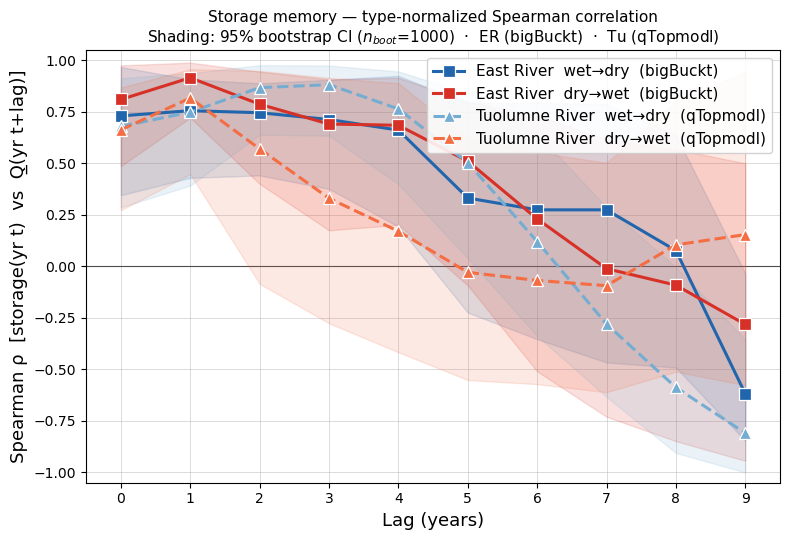

Saved → ess-project/figures/synthetic_fig_memory_decay.png


In [15]:
# Storage memory — Spearman r with 1000-sample bootstrap CIs, type-normalized Q
# Spearman: rank-based, robust to non-normality and outliers
# Bootstrap CI: resamples (S[t], Q_norm[t+lag]) pairs with replacement

import xarray as xr, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE     = Path('/scratch/dlhogan/ess-project-data')
SYNTH    = 'synthetic_extended_runs'
SUMM_CSV = BASE / 'synthetic_summary.csv'
N_BOOT   = 1000

FOCUS_RUNS = [
    ('East_River_distributed_elevTPI',     'bigBuckt', 'wet10_dry10'),
    ('East_River_distributed_elevTPI',     'bigBuckt', 'dry10_wet10'),
    ('Tuolumne_River_distributed_elevTPI', 'qTopmodl', 'wet10_dry10'),
    ('Tuolumne_River_distributed_elevTPI', 'qTopmodl', 'dry10_wet10'),
]
FIRST_WY = 2021
LAST_WY  = 2040

STYLE = {
    ('East_River_distributed_elevTPI',     'wet10_dry10'): ('#2166ac', 's', '-',  'East River  wet→dry  (bigBuckt)'),
    ('East_River_distributed_elevTPI',     'dry10_wet10'): ('#d73027', 's', '-',  'East River  dry→wet  (bigBuckt)'),
    ('Tuolumne_River_distributed_elevTPI', 'wet10_dry10'): ('#74add1', '^', '--', 'Tuolumne River  wet→dry  (qTopmodl)'),
    ('Tuolumne_River_distributed_elevTPI', 'dry10_wet10'): ('#f46d43', '^', '--', 'Tuolumne River  dry→wet  (qTopmodl)'),
}

# ── helpers ───────────────────────────────────────────────────────────────
_summ = pd.read_csv(SUMM_CSV)

_area_cache = {}
def _get_area_w(domain):
    if domain not in _area_cache:
        with xr.open_dataset(BASE / f'domain_{domain}/settings/SUMMA/attributes.nc') as ds:
            a = ds['HRUarea'].values.ravel().astype(float)
            _area_cache[domain] = (float(a.sum()), a / a.sum())
    return _area_cache[domain]

def _am_np(arr, w):
    return (arr * w[None, :arr.shape[1]]).sum(axis=1) if arr.ndim == 2 else arr.ravel()

def bootstrap_spearman(x, y, n_boot=N_BOOT, seed=42):
    rng = np.random.default_rng(seed)
    n = len(x)
    rs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        rs[i] = spearmanr(x[idx], y[idx])[0]
    return rs

def load_annual(domain, model, pattern):
    nc = (BASE / f'domain_{domain}/simulations/{SYNTH}'
          f'/{model}/{pattern}/output'
          f'/synthetic_{domain}_{model}_{pattern}_timestep.nc')
    if not nc.exists():
        print(f'  MISSING: {nc}'); return None
    area, w = _get_area_w(domain)
    with xr.open_dataset(nc) as ds:
        ti    = pd.DatetimeIndex(ds.time.values)
        q_day = (pd.Series(ds['averageRoutedRunoff'].mean(dim='gru').values.ravel() * area, index=ti)
                 .resample('1D').mean())
        soil  = _am_np(ds['scalarTotalSoilLiq'].values, w)
        swe   = _am_np(ds['scalarSWE'].values, w)
        aq_key = next((v for v in ['scalarAquiferStorage_mean', 'scalarAquiferStorage']
                       if v in ds), None)
        aq = (_am_np(ds[aq_key].values, w) * 1000
              if (aq_key and model == 'bigBuckt') else np.zeros(len(soil)))
        stor_h = pd.Series(soil + swe + aq, index=ti)

    yt_lkp = _summ[
        (_summ['domain'] == domain) & (_summ['model'] == model) & (_summ['pattern'] == pattern)
    ].set_index('water_year')['year_type']

    rows = []
    for wy in range(FIRST_WY, LAST_WY + 1):
        s = pd.Timestamp(f'{wy-1}-10-01');  e = pd.Timestamp(f'{wy}-09-30 23:59')
        q_yr = q_day[(q_day.index >= s) & (q_day.index <= e)]
        if len(q_yr) < 300: continue
        q_mm = float(q_yr.sum() * 86400 / area * 1000)
        sep30 = stor_h[(stor_h.index >= pd.Timestamp(f'{wy}-09-30')) &
                       (stor_h.index <  pd.Timestamp(f'{wy}-10-01'))]
        stor_eowy = float(sep30.mean()) if len(sep30) else np.nan
        rows.append({'water_year': wy, 'q_mm': q_mm, 'storage_mm': stor_eowy,
                     'year_type': yt_lkp.get(wy, np.nan)})

    df = pd.DataFrame(rows).sort_values('water_year').reset_index(drop=True)
    q_norm = df['q_mm'].copy().astype(float)
    for yt in ['W', 'D']:
        mask = df['year_type'] == yt
        if mask.sum() > 0:
            q_norm[mask] -= df.loc[mask, 'q_mm'].mean()
    df['q_norm'] = q_norm
    return df

# ── Load and compute correlations + bootstrap CIs ─────────────────────────
print(f'Loading data and bootstrapping (n={N_BOOT}) Spearman r...')
run_lag_r = {}

for dom, mod, pat in FOCUS_RUNS:
    df = load_annual(dom, mod, pat)
    if df is None or df['storage_mm'].isna().all(): continue
    S = df['storage_mm'].values
    Q = df['q_norm'].values
    lag_r = {}
    for lag in range(0, 10):
        n = len(S) - lag
        if n < 4: continue
        r, p = spearmanr(S[:n], Q[lag:lag+n])
        boot  = bootstrap_spearman(S[:n], Q[lag:lag+n])
        lag_r[lag] = dict(r=r, p=p, n=n,
                          ci_lo=np.percentile(boot, 2.5),
                          ci_hi=np.percentile(boot, 97.5))
    run_lag_r[(dom, pat)] = lag_r
    lags_str = '  '.join(f'L{l}={lag_r[l]["r"]:+.2f}' for l in sorted(lag_r))
    print(f'  {dom[-16:]}/{pat}:  {lags_str}')

# ── Single subplot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5.5))

for dom, mod, pat in FOCUS_RUNS:
    key = (dom, pat)
    if key not in run_lag_r: continue
    col, mk, ls, lbl = STYLE[key]
    lags   = sorted(run_lag_r[key])
    r_vals = [run_lag_r[key][l]['r']     for l in lags]
    ci_lo  = [run_lag_r[key][l]['ci_lo'] for l in lags]
    ci_hi  = [run_lag_r[key][l]['ci_hi'] for l in lags]
    ax.fill_between(lags, ci_lo, ci_hi, color=col, alpha=0.15, zorder=3)
    ax.plot(lags, r_vals, color=col, marker=mk, ls=ls,
            lw=2.2, ms=9, markerfacecolor=col, markeredgecolor='white',
            markeredgewidth=0.9, label=lbl, zorder=4)

ax.axhline(0, color='0.3', lw=0.8)
ax.set_xticks(range(0, 10))
ax.set_xlim(-0.5, 9.5)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel('Lag (years)', fontsize=13)
ax.set_ylabel('Spearman ρ  [storage(yr t)  vs  Q̲(yr t+lag)]', fontsize=13)
ax.set_title(
    'Storage memory — type-normalized Spearman correlation\n'
    r'Shading: 95% bootstrap CI ($n_{boot}$=1000)  ·  '
    'ER (bigBuckt)  ·  Tu (qTopmodl)',
    fontsize=11)
ax.legend(fontsize=11, loc='upper right', frameon=True, framealpha=0.88)
ax.grid(True, lw=0.7, alpha=0.45)

plt.tight_layout()
out = Path('ess-project/figures/synthetic_fig_memory_decay.png')
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')


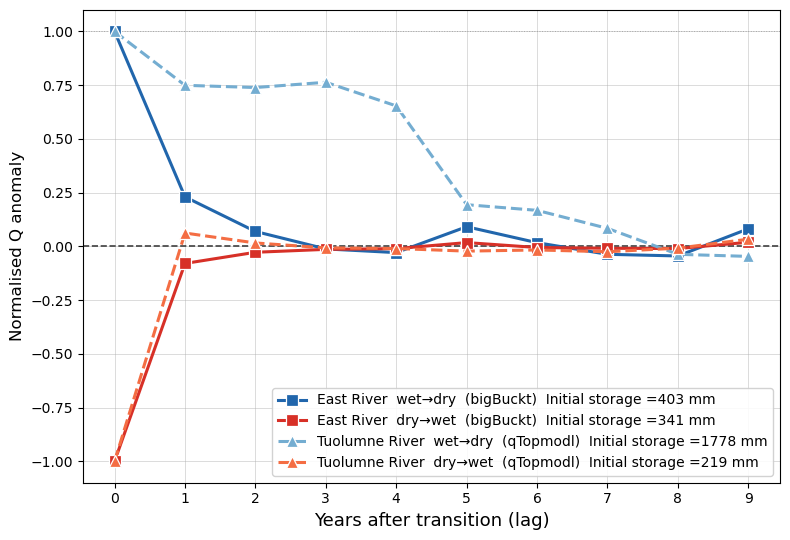

Saved → ess-project/figures/synthetic_fig_memory_summary.png


In [5]:
# Transition memory — how quickly does streamflow return to normal after the forcing shift?
#
# Anchor: year 10 (WY2030) = end of first forcing block (wet or dry)
# Q_ref  = mean Q of final 3 years (WY2038-2040) — treated as "fully adjusted" to new forcing
# Q_anom = Q[year 10+lag] - Q_ref    (absolute deviation from adjusted baseline)
# Q_frac = Q_anom[lag] / Q_anom[lag=1]  (fraction of year-1 anomaly remaining; starts at 1.0)
#
# Annotated with S[WY2030] = initial storage at the transition

TRANSITION_WY = 2030
REF_YEARS     = [2038, 2039, 2040]

fig, ax = plt.subplots(figsize=(8, 5.5))

for dom, mod, pat in FOCUS_RUNS:
    df = load_annual(dom, mod, pat)
    if df is None: continue

    col, mk, ls, _ = STYLE[(dom, pat)]

    # Fully-adjusted reference Q = mean of last 3 years of run
    q_ref = df[df['water_year'].isin(REF_YEARS)]['q_mm'].mean()

    # Post-transition years (lag 1-10)
    post = df[df['water_year'] > TRANSITION_WY].copy()
    post['lag']    = post['water_year'] - TRANSITION_WY
    post['q_anom'] = post['q_mm'] - q_ref

    # Normalise so all series start at 1.0 at lag=1
    anom_yr1 = post.loc[post['lag'] == 1, 'q_anom'].values
    if not len(anom_yr1) or anom_yr1[0] == 0:
        continue
    post['q_frac'] = post['q_anom'] / abs(anom_yr1[0])

    # Initial storage at the transition
    s0_row = df[df['water_year'] == TRANSITION_WY]['storage_mm'].values
    s0_label = f'  Initial storage ={s0_row[0]:.0f} mm' if len(s0_row) else ''

    # Build label with S0
    base_lbl = STYLE[(dom, pat)][3]
    lbl = base_lbl + s0_label

    ax.plot(post['lag']-1, post['q_frac'], color=col, marker=mk, ls=ls,
            lw=2.2, ms=9, markerfacecolor=col, markeredgecolor='white',
            markeredgewidth=0.9, label=lbl, zorder=4)

ax.axhline(0, color='0.25', lw=1.2, ls='--', zorder=2)
ax.axhline(1, color='0.65', lw=0.7, ls=':', zorder=2)

# set x ticks to 0-9 
ax.set_xticks(range(0, 10))
ax.set_xticklabels(range(0, 10))
# ax.set_xlim(0.5, 10.5)
ax.set_xlabel('Years after transition (lag)', fontsize=13)
ax.set_ylabel('Normalised Q anomaly', fontsize=12)
# ax.set_title(
#     'Return-to-normal after forcing transition at year 10\n'
#     r'$Q_{ref}$ = mean of WY2038–2040  ·  normalised to 1.0 at lag = 1'
#     '\nAnnotated with Sep-30 storage at transition (S₀)',
#     fontsize=11)
ax.legend(fontsize=10, loc='lower right', frameon=True, framealpha=0.88)
ax.grid(True, lw=0.7, alpha=0.45)

plt.tight_layout()
out = Path('ess-project/figures/synthetic_fig_memory_summary.png')
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')
